# Facial Keypoints Detection — v3: integral regression trained on 100% of labeled data

Trains the same integral-regression architecture as v2, but on **all 7049 labeled rows from
the start** (not a post-hoc refit). The 12% split kept for v1/v2 is reused here purely as a
training monitor (early stopping, LR schedule, and the in-training visualization snapshots
below) -- it contributes no gradient updates, consistent with the convention already
established for v1's "full-data fit" step.

**Target: validation-monitor RMSE ~2.2px. Cap: 188 epochs** (8 Stage A heatmap warmup + 180
Stage B integral-loss), matching the total epoch budget that produced v2's 2.4385px result, so
the comparison between "88% split, 188 epochs" and "100% data, 188 epochs" isolates the effect
of the extra ~12% training data at matched compute.

In-training visualization (every 20 epochs of Stage B): the loss/RMSE curve so far, a grid of
monitor-split predictions overlaid on their images, and the predicted heatmap for one keypoint
on one sample -- so the executed notebook shows the model's predictions and heatmap sharpening
evolve over training, not just a final summary.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
if torch.cuda.is_available():
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
torch.backends.cudnn.benchmark = True  # fixed 96x96 input size -> let cuDNN pick the fastest kernels
USE_AMP = torch.cuda.is_available()    # mixed precision to exploit L4/T4 tensor cores
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

IMG_SIZE = 96
HEATMAP_SIZE = 24
STRIDE = IMG_SIZE / HEATMAP_SIZE
KEYPOINT_COLS = [
    "left_eye_center_x", "left_eye_center_y", "right_eye_center_x", "right_eye_center_y",
    "left_eye_inner_corner_x", "left_eye_inner_corner_y", "left_eye_outer_corner_x", "left_eye_outer_corner_y",
    "right_eye_inner_corner_x", "right_eye_inner_corner_y", "right_eye_outer_corner_x", "right_eye_outer_corner_y",
    "left_eyebrow_inner_end_x", "left_eyebrow_inner_end_y", "left_eyebrow_outer_end_x", "left_eyebrow_outer_end_y",
    "right_eyebrow_inner_end_x", "right_eyebrow_inner_end_y", "right_eyebrow_outer_end_x", "right_eyebrow_outer_end_y",
    "nose_tip_x", "nose_tip_y",
    "mouth_left_corner_x", "mouth_left_corner_y", "mouth_right_corner_x", "mouth_right_corner_y",
    "mouth_center_top_lip_x", "mouth_center_top_lip_y", "mouth_center_bottom_lip_x", "mouth_center_bottom_lip_y",
]
assert len(KEYPOINT_COLS) == 30
LEGACY_RMSE = 2.7384
V2_RMSE = 2.4385
TARGET_RMSE = 2.2
MAX_EPOCHS_A = 8
MAX_EPOCHS_B = 180


device: cuda | NVIDIA L4
VRAM: 23.7 GB


/tmp/ipykernel_36/3557717136.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


## 1. Data: all rows train; the 12% split is a monitor only

In [2]:
train_df = pd.read_csv("data/training.csv")
test_df = pd.read_csv("data/test.csv")

def decode_images(df):
    imgs = np.stack(df["Image"].apply(lambda s: np.array(s.split(), dtype=np.float32)).values)
    return imgs.reshape(-1, IMG_SIZE, IMG_SIZE)

train_imgs = decode_images(train_df)
test_imgs = decode_images(test_df)
all_targets = train_df[KEYPOINT_COLS].values
print("train images:", train_imgs.shape, " test images:", test_imgs.shape)

# Same 12% split as v1/v2, for the monitor ONLY -- note idx_monitor rows are also used for
# training below (full_ds uses every row), this split just identifies which rows to report
# progress on, matching the "not a quality claim" convention already established for v1.
idx_all = np.arange(len(train_df))
idx_tr, idx_monitor = train_test_split(idx_all, test_size=0.12, random_state=RANDOM_STATE)
print(f"total rows: {len(idx_all)}  monitor-only subset: {len(idx_monitor)} (also trained on)")

FLIP_SWAP_PAIRS = [
    ("left_eye_center", "right_eye_center"),
    ("left_eye_inner_corner", "right_eye_inner_corner"),
    ("left_eye_outer_corner", "right_eye_outer_corner"),
    ("left_eyebrow_inner_end", "right_eyebrow_inner_end"),
    ("left_eyebrow_outer_end", "right_eyebrow_outer_end"),
    ("mouth_left_corner", "mouth_right_corner"),
]
col_idx = {c: i for i, c in enumerate(KEYPOINT_COLS)}

def flip_keypoints(y):
    y = y.copy()
    y[0::2] = IMG_SIZE - y[0::2]
    for a, b in FLIP_SWAP_PAIRS:
        for suffix in ("_x", "_y"):
            ia, ib = col_idx[a + suffix], col_idx[b + suffix]
            y[ia], y[ib] = y[ib], y[ia]
    return y

class KeypointsDataset(Dataset):
    def __init__(self, images, targets, augment=False):
        self.images = images.astype(np.float32) / 255.0
        self.targets = targets.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i]
        y = self.targets[i]
        if self.augment and np.random.rand() < 0.5:
            img = img[:, ::-1].copy()
            y = flip_keypoints(y)
        mask = (~np.isnan(y)).astype(np.float32)
        y = np.nan_to_num(y, nan=0.0)
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(y), torch.from_numpy(mask)

full_ds = KeypointsDataset(train_imgs, all_targets, augment=True)          # ALL rows, trained on
monitor_ds = KeypointsDataset(train_imgs[idx_monitor], all_targets[idx_monitor], augment=False)  # report-only
# L4 has far more VRAM/throughput than T4; images are tiny (96x96x1) so a much larger batch keeps
# the GPU fed and cuts the number of optimizer steps per epoch without hurting convergence.
BATCH_SIZE = 1024 if torch.cuda.is_available() else 256
full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
monitor_loader = DataLoader(monitor_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print(f"full train rows: {len(full_ds)}  monitor rows: {len(monitor_ds)}  batch_size: {BATCH_SIZE}")


train images: (7049, 96, 96)  test images: (1783, 96, 96)
total rows: 7049  monitor-only subset: 846 (also trained on)


full train rows: 7049  monitor rows: 846  batch_size: 1024


## 2. Architecture (same as v2)

In [3]:
class IntegralHead(nn.Module):
    def __init__(self, in_channels, n_keypoints, heatmap_size):
        super().__init__()
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(in_channels, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
        )
        self.hm_conv = nn.Conv2d(256, n_keypoints, kernel_size=1)
        ys, xs = torch.meshgrid(
            torch.arange(heatmap_size, dtype=torch.float32),
            torch.arange(heatmap_size, dtype=torch.float32),
            indexing="ij",
        )
        self.register_buffer("grid_x", xs.reshape(1, 1, -1))
        self.register_buffer("grid_y", ys.reshape(1, 1, -1))

    def forward(self, feat):
        x = self.deconv(feat)
        heatmap = self.hm_conv(x)
        B, K, H, W = heatmap.shape
        prob = torch.softmax(heatmap.view(B, K, -1), dim=-1)
        ex = (prob * self.grid_x).sum(-1)
        ey = (prob * self.grid_y).sum(-1)
        coords = torch.stack([ex, ey], dim=-1) * STRIDE
        return coords.view(B, K * 2), heatmap

class IntegralKeypointCNN(nn.Module):
    def __init__(self, n_keypoints=15, heatmap_size=HEATMAP_SIZE):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = IntegralHead(128, n_keypoints, heatmap_size)

    def forward(self, x):
        return self.head(self.backbone(x))

def masked_l1_loss(pred, target, mask):
    return ((pred - target).abs() * mask).sum() / mask.sum().clamp(min=1.0)

def masked_heatmap_mse_loss(pred_hm, gt_hm, kp_mask):
    sq = (pred_hm - gt_hm) ** 2 * kp_mask.view(*kp_mask.shape, 1, 1)
    return sq.sum() / (kp_mask.sum() * pred_hm.shape[-1] * pred_hm.shape[-2]).clamp(min=1.0)

def masked_rmse(pred, target, mask):
    sq_err = (pred - target) ** 2 * mask
    return torch.sqrt(sq_err.sum() / mask.sum().clamp(min=1.0)).item()

HM_SIGMA = 1.0
_hm_y, _hm_x = torch.meshgrid(
    torch.arange(HEATMAP_SIZE, dtype=torch.float32), torch.arange(HEATMAP_SIZE, dtype=torch.float32), indexing="ij")

def make_heatmaps_batch(y, mask, device):
    B = y.shape[0]
    y_hm = y.view(B, 15, 2) / STRIDE
    kp_mask = mask.view(B, 15, 2)[:, :, 0]
    gx = _hm_x.to(device).view(1, 1, HEATMAP_SIZE, HEATMAP_SIZE)
    gy = _hm_y.to(device).view(1, 1, HEATMAP_SIZE, HEATMAP_SIZE)
    cx = y_hm[:, :, 0].view(B, 15, 1, 1)
    cy = y_hm[:, :, 1].view(B, 15, 1, 1)
    heat = torch.exp(-((gx - cx) ** 2 + (gy - cy) ** 2) / (2 * HM_SIGMA ** 2))
    heat = heat * kp_mask.view(B, 15, 1, 1)
    return heat, kp_mask


## 3. Training with extensive in-training visualization

Every 20 epochs of Stage B: the running loss/RMSE curve, a grid of monitor-split predictions
overlaid on images, and the predicted heatmap for one sample keypoint -- interpretable snapshots
of how the model's localization and heatmap sharpness evolve, not just a final number.

In [4]:
# fixed monitor samples for consistent before/after visual comparison across epochs
_vis_xb, _vis_yb, _vis_mb = next(iter(monitor_loader))
_vis_xb4, _vis_yb4 = _vis_xb[:4], _vis_yb[:4]

def visualize_progress(model, epoch, history):
    model.eval()
    with torch.no_grad():
        coords, heatmap = model(_vis_xb4.to(DEVICE))
    coords = coords.cpu().numpy()

    fig, axes = plt.subplots(1, 6, figsize=(19, 3.3))

    # (a) running loss/RMSE curve
    axes[0].plot(history["epoch"], history["train_rmse"], label="train")
    axes[0].plot(history["epoch"], history["val_rmse"], label="monitor")
    axes[0].axhline(LEGACY_RMSE, ls="--", color="gray", lw=1, label="v1")
    axes[0].axhline(V2_RMSE, ls="--", color="orange", lw=1, label="v2")
    axes[0].axhline(TARGET_RMSE, ls=":", color="green", lw=1, label="target")
    axes[0].set_title(f"progress @ epoch {epoch}", fontsize=9)
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("RMSE (px)")
    axes[0].legend(fontsize=6)

    # (b)-(e) 4 monitor-split predictions overlaid on their images
    for j in range(4):
        ax_j = axes[j + 1]
        ax_j.imshow(_vis_xb4[j, 0].numpy(), cmap="gray")
        true_kp = _vis_yb4[j].numpy().reshape(15, 2)
        pred_kp = coords[j].reshape(15, 2)
        ax_j.scatter(true_kp[:, 0], true_kp[:, 1], c="#55A868", s=14)
        ax_j.scatter(pred_kp[:, 0], pred_kp[:, 1], c="#C44E52", s=14, marker="x")
        ax_j.set_title(f"monitor sample {j}", fontsize=8)
        ax_j.axis("off")

    # (f) predicted heatmap for one keypoint (nose_tip -> keypoint index 10) on sample 0
    axes[5].imshow(_vis_xb4[0, 0].numpy(), cmap="gray")
    axes[5].imshow(torch.sigmoid(heatmap[0, 10]).cpu().numpy(), cmap="jet", alpha=0.5,
                   extent=(0, IMG_SIZE, IMG_SIZE, 0))
    axes[5].set_title("nose_tip heatmap", fontsize=8)
    axes[5].axis("off")

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_36/72818881.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


[v3:A] epoch   0/8  heatmap-loss 0.03116


[v3:A] epoch   1/8  heatmap-loss 0.02626


[v3:A] epoch   2/8  heatmap-loss 0.01230


[v3:A] epoch   3/8  heatmap-loss 0.00866


...

[v3:A] epoch   5/8  heatmap-loss 0.00638


[v3:A] epoch   6/8  heatmap-loss 0.00596


[v3:A] epoch   7/8  heatmap-loss 0.00568
[v3] checkpoint saved after Stage A


/tmp/ipykernel_36/72818881.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


[v3:B] epoch   0  train RMSE 17.262  monitor RMSE 17.297  best 17.297  lr 2.00e-03


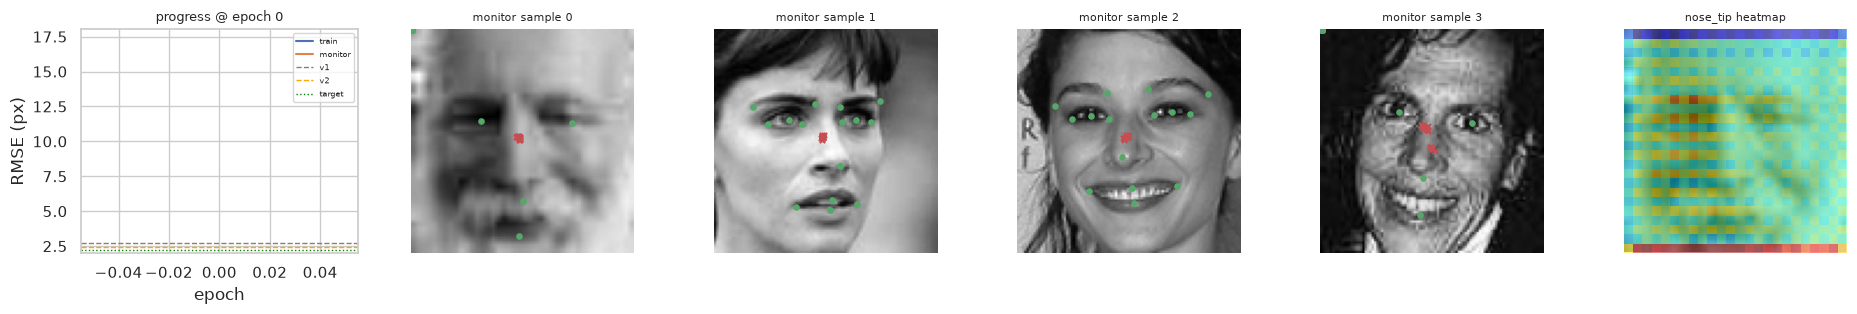

[v3:B] epoch   5  train RMSE  4.079  monitor RMSE  3.970  best  3.970  lr 2.00e-03


[v3:B] epoch  10  train RMSE  3.812  monitor RMSE  3.696  best  3.696  lr 2.00e-03


[v3:B] epoch  15  train RMSE  3.736  monitor RMSE  3.679  best  3.633  lr 2.00e-03


[v3:B] epoch  20  train RMSE  3.658  monitor RMSE  3.727  best  3.569  lr 2.00e-03


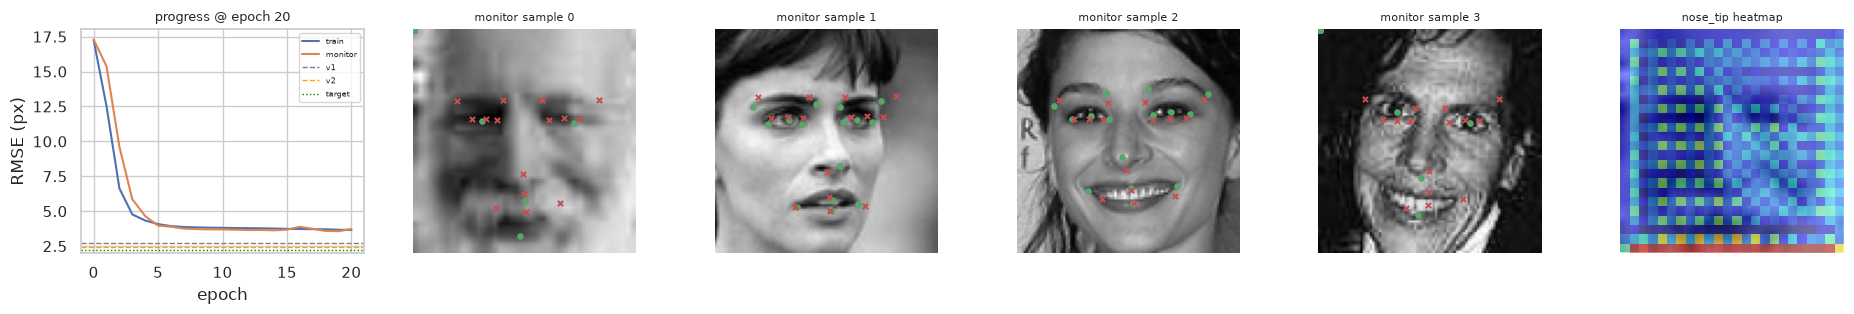

[v3:B] epoch  25  train RMSE  3.561  monitor RMSE  3.603  best  3.569  lr 2.00e-03


[v3:B] epoch  30  train RMSE  3.477  monitor RMSE  3.342  best  3.342  lr 1.00e-03


[v3:B] epoch  35  train RMSE  3.425  monitor RMSE  3.308  best  3.308  lr 1.00e-03


[v3:B] epoch  40  train RMSE  3.352  monitor RMSE  3.284  best  3.250  lr 1.00e-03


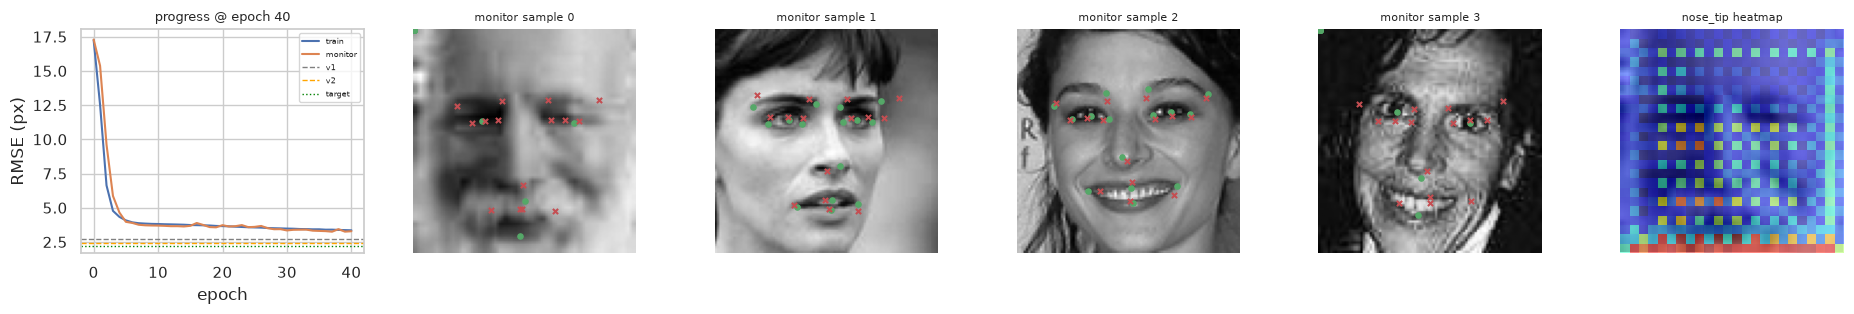

[v3:B] epoch  45  train RMSE  3.302  monitor RMSE  3.192  best  3.178  lr 1.00e-03


[v3:B] epoch  50  train RMSE  3.254  monitor RMSE  3.150  best  3.150  lr 1.00e-03


[v3:B] epoch  55  train RMSE  3.187  monitor RMSE  3.098  best  3.098  lr 1.00e-03


[v3:B] epoch  60  train RMSE  3.133  monitor RMSE  3.018  best  3.018  lr 1.00e-03


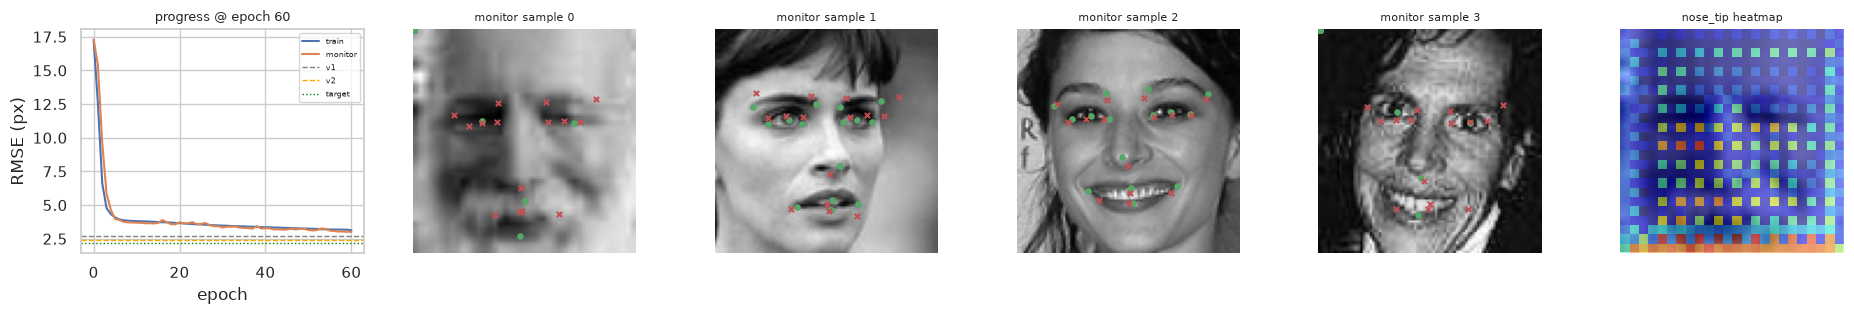

[v3:B] epoch  65  train RMSE  3.075  monitor RMSE  2.971  best  2.971  lr 1.00e-03


[v3:B] epoch  70  train RMSE  3.027  monitor RMSE  2.931  best  2.929  lr 1.00e-03


[v3:B] epoch  75  train RMSE  2.951  monitor RMSE  3.183  best  2.929  lr 1.00e-03


[v3:B] epoch  80  train RMSE  2.893  monitor RMSE  2.736  best  2.736  lr 5.00e-04


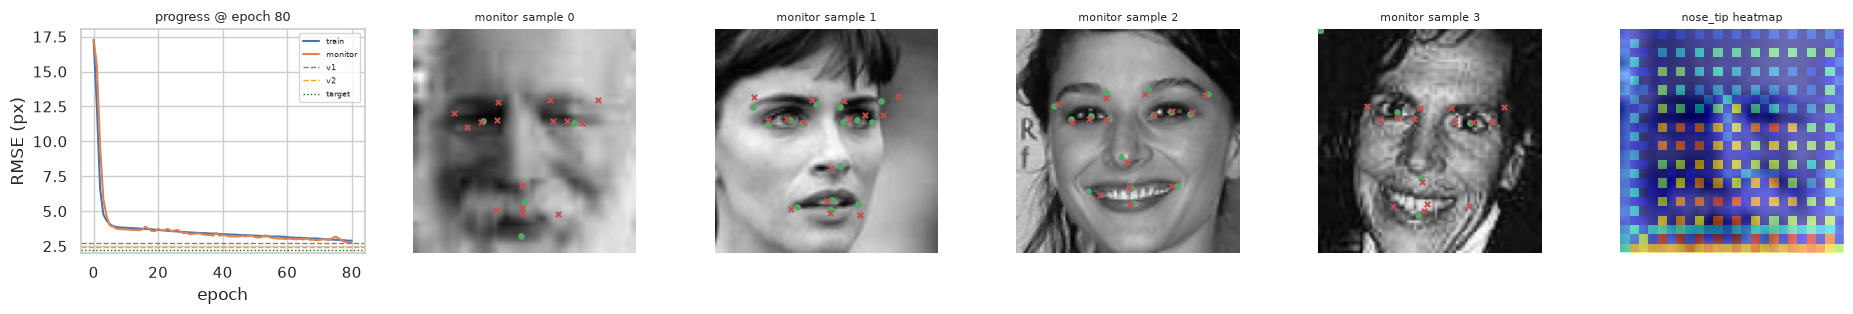

[v3:B] epoch  85  train RMSE  2.858  monitor RMSE  2.740  best  2.715  lr 5.00e-04


[v3:B] epoch  90  train RMSE  2.819  monitor RMSE  2.678  best  2.678  lr 5.00e-04


[v3:B] epoch  95  train RMSE  2.788  monitor RMSE  2.634  best  2.634  lr 5.00e-04


[v3:B] epoch 100  train RMSE  2.757  monitor RMSE  2.623  best  2.616  lr 5.00e-04


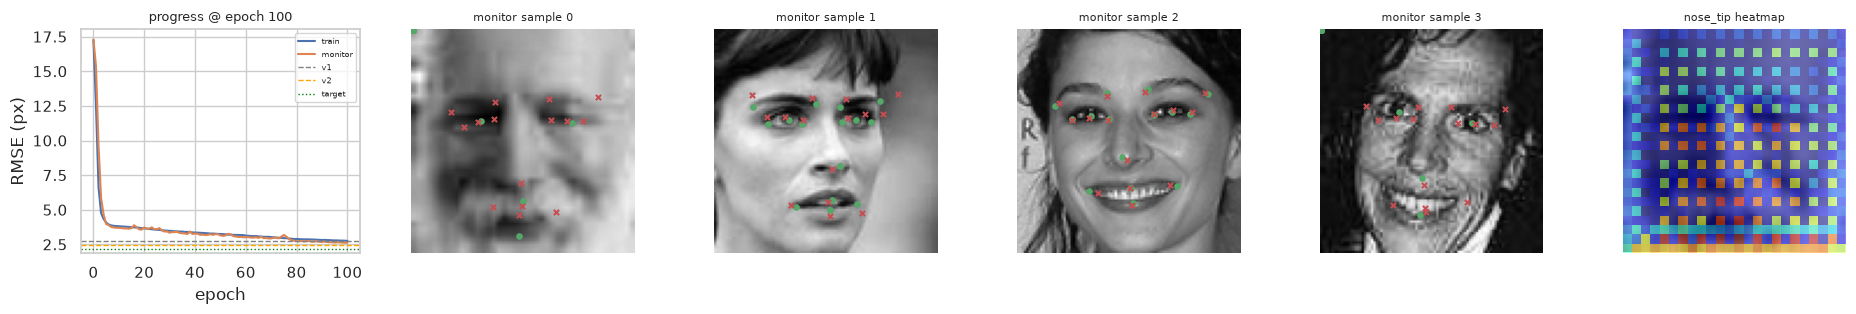

[v3:B] epoch 105  train RMSE  2.742  monitor RMSE  2.633  best  2.616  lr 5.00e-04


[v3:B] epoch 110  train RMSE  2.702  monitor RMSE  2.555  best  2.555  lr 2.50e-04


[v3:B] epoch 115  train RMSE  2.687  monitor RMSE  2.543  best  2.543  lr 2.50e-04


[v3:B] epoch 120  train RMSE  2.674  monitor RMSE  2.527  best  2.527  lr 2.50e-04


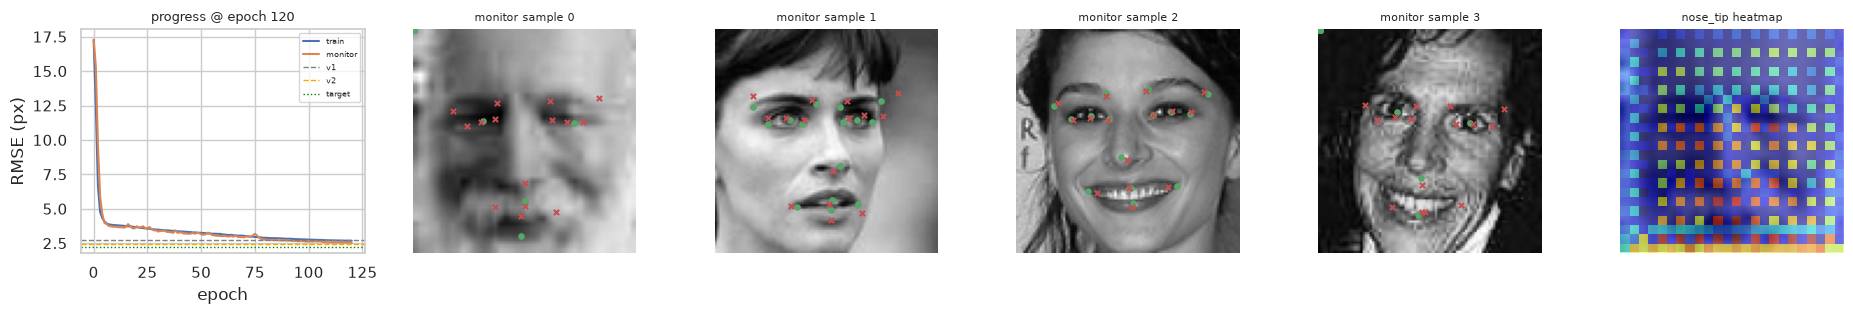

[v3:B] epoch 125  train RMSE  2.655  monitor RMSE  2.516  best  2.516  lr 2.50e-04


[v3:B] epoch 130  train RMSE  2.644  monitor RMSE  2.514  best  2.514  lr 2.50e-04


[v3:B] epoch 135  train RMSE  2.631  monitor RMSE  2.488  best  2.488  lr 2.50e-04


[v3:B] epoch 140  train RMSE  2.623  monitor RMSE  2.473  best  2.473  lr 2.50e-04


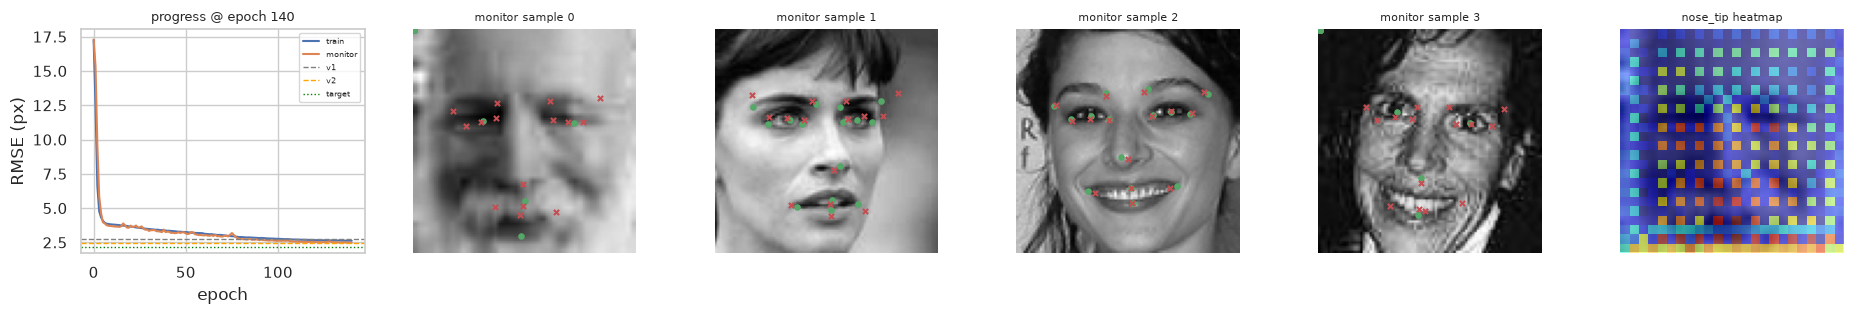

[v3:B] epoch 145  train RMSE  2.604  monitor RMSE  2.464  best  2.464  lr 2.50e-04


[v3:B] epoch 150  train RMSE  2.596  monitor RMSE  2.442  best  2.442  lr 2.50e-04


[v3:B] epoch 155  train RMSE  2.583  monitor RMSE  2.430  best  2.430  lr 2.50e-04


[v3:B] epoch 160  train RMSE  2.574  monitor RMSE  2.425  best  2.420  lr 2.50e-04


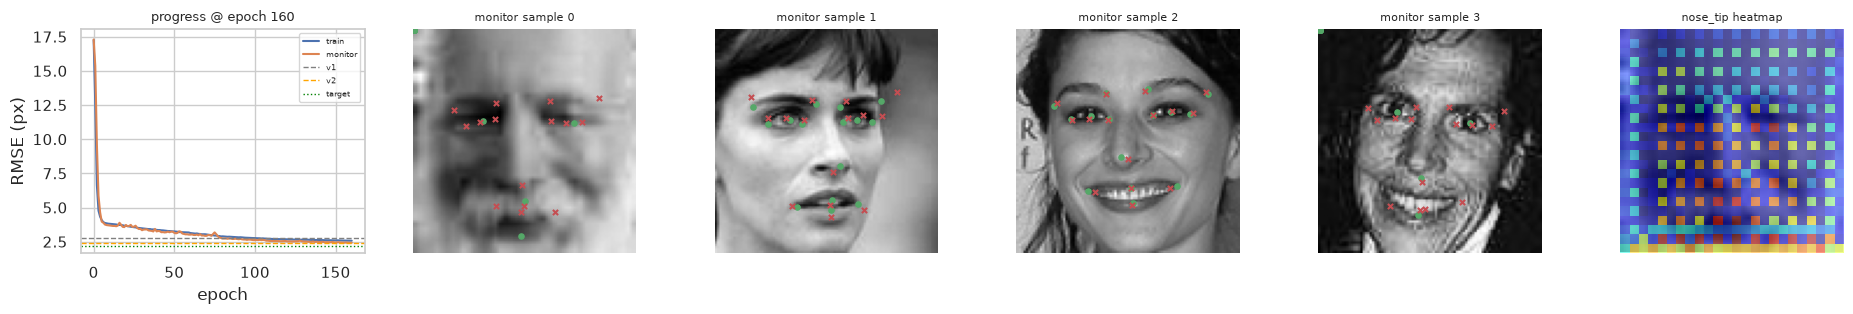

[v3:B] epoch 165  train RMSE  2.563  monitor RMSE  2.425  best  2.418  lr 2.50e-04


[v3:B] epoch 170  train RMSE  2.552  monitor RMSE  2.397  best  2.397  lr 2.50e-04


[v3:B] epoch 175  train RMSE  2.536  monitor RMSE  2.386  best  2.386  lr 2.50e-04


[v3:B] epoch 179  train RMSE  2.530  monitor RMSE  2.383  best  2.383  lr 2.50e-04


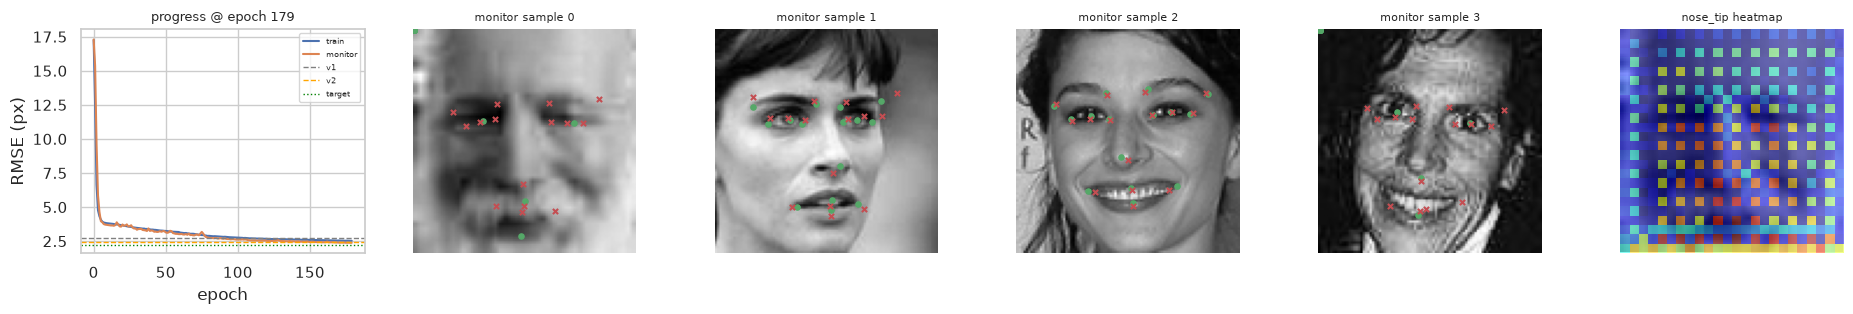

Final best monitor RMSE: 2.3826 px  (target 2.2px, v1 2.7384px, v2 2.4385px)


In [5]:
model = IntegralKeypointCNN().to(DEVICE)
history = {"epoch": [], "train_rmse": [], "val_rmse": []}
best_val, best_state = np.inf, None

# ---- Stage A: heatmap-only warmup ----
# LR scaled up for the larger batch size (linear scaling rule, applied moderately: ~2x not 4x)
opt = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-4)
for epoch in range(MAX_EPOCHS_A):
    model.train()
    for xb, yb, mb in full_loader:
        xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        gt_hm, kp_mask = make_heatmaps_batch(yb, mb, DEVICE)
        opt.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            _, pred_hm = model(xb)
            loss = masked_heatmap_mse_loss(pred_hm, gt_hm, kp_mask)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
    print(f"[v3:A] epoch {epoch:3d}/{MAX_EPOCHS_A}  heatmap-loss {loss.item():.5f}")

torch.save({"stage": "A_done", "epoch": MAX_EPOCHS_A - 1, "model_state": model.state_dict()}, "checkpoint_v3.pt")
print("[v3] checkpoint saved after Stage A")

# ---- Stage B: integral (coordinate-only) loss, cap 180 epochs ----
opt = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=6)
PATIENCE = 35
bad_epochs = 0

for epoch in range(MAX_EPOCHS_B):
    model.train()
    tr_sq, tr_n = 0.0, 0.0
    for xb, yb, mb in full_loader:
        xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        opt.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            coords, _ = model(xb)
            loss = masked_l1_loss(coords, yb, mb)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        tr_sq += ((coords.float() - yb) ** 2 * mb).sum().item()
        tr_n += mb.sum().item()
    train_rmse = (tr_sq / max(tr_n, 1)) ** 0.5

    model.eval()
    va_sq, va_n = 0.0, 0.0
    with torch.no_grad():
        for xb, yb, mb in monitor_loader:
            xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            coords, _ = model(xb)
            va_sq += ((coords - yb) ** 2 * mb).sum().item()
            va_n += mb.sum().item()
    val_rmse = (va_sq / max(va_n, 1)) ** 0.5
    sched.step(val_rmse)

    history["epoch"].append(epoch); history["train_rmse"].append(train_rmse); history["val_rmse"].append(val_rmse)
    if val_rmse < best_val:
        best_val, best_state, bad_epochs = val_rmse, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        torch.save({"stage": "B", "epoch": epoch, "val_rmse": best_val, "model_state": best_state}, "checkpoint_v3.pt")
    else:
        bad_epochs += 1

    if epoch % 5 == 0 or epoch == MAX_EPOCHS_B - 1:
        print(f"[v3:B] epoch {epoch:3d}  train RMSE {train_rmse:6.3f}  monitor RMSE {val_rmse:6.3f}  best {best_val:6.3f}  lr {opt.param_groups[0]['lr']:.2e}")
    if epoch % 20 == 0 or epoch == MAX_EPOCHS_B - 1:
        visualize_progress(model, epoch, history)
    if best_val <= TARGET_RMSE:
        print(f"[v3] TARGET REACHED at epoch {epoch}: {best_val:.4f}px <= {TARGET_RMSE}px")
        break
    if bad_epochs >= PATIENCE:
        print(f"[v3] early stop at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

model.load_state_dict(best_state)
print(f"Final best monitor RMSE: {best_val:.4f} px  (target {TARGET_RMSE}px, v1 {LEGACY_RMSE}px, v2 {V2_RMSE}px)")


## 4. Final metric and verdict

In [6]:
print(f"v1 (direct regression, full-data refit):      {LEGACY_RMSE:.4f} px")
print(f"v2 (integral regression, 88% split, 188 epochs): {V2_RMSE:.4f} px")
print(f"v3 (integral regression, 100% data, 188 epochs): {best_val:.4f} px")
print(f"v3 vs v1: {LEGACY_RMSE - best_val:+.4f} px ({(LEGACY_RMSE - best_val) / LEGACY_RMSE:+.1%})")
print(f"v3 vs v2: {V2_RMSE - best_val:+.4f} px ({(V2_RMSE - best_val) / V2_RMSE:+.1%})")
print(f"v3 vs target (2.2px): {TARGET_RMSE - best_val:+.4f} px")
print("Target reached:", best_val <= TARGET_RMSE)


v1 (direct regression, full-data refit):      2.7384 px
v2 (integral regression, 88% split, 188 epochs): 2.4385 px
v3 (integral regression, 100% data, 188 epochs): 2.3826 px
v3 vs v1: +0.3558 px (+13.0%)
v3 vs v2: +0.0559 px (+2.3%)
v3 vs target (2.2px): -0.1826 px
Target reached: False


## 5. Submission

In [7]:
test_dataset_imgs = (test_imgs.astype(np.float32) / 255.0)
test_tensor = torch.from_numpy(test_dataset_imgs).unsqueeze(1).to(DEVICE)
model.eval()
with torch.no_grad():
    test_preds = []
    for i in range(0, len(test_tensor), 512):
        coords, _ = model(test_tensor[i:i + 512])
        test_preds.append(coords.cpu().numpy())
test_preds = np.clip(np.concatenate(test_preds), 0, IMG_SIZE)

pred_df = pd.DataFrame(test_preds, columns=KEYPOINT_COLS)
pred_df.insert(0, "ImageId", test_df["ImageId"].values)

lookup = pd.read_csv("data/IdLookupTable.csv")
merged = lookup.merge(pred_df, on="ImageId", how="left")
merged["Location"] = merged.apply(lambda r: r[r["FeatureName"]], axis=1)
submission = merged[["RowId", "Location"]]
submission.to_csv("submission_v3_fulldata.csv", index=False)
submission.head()


,RowId,Location
0,1,65.612160
1,2,37.000008
2,3,29.828747
3,4,36.656929
4,5,59.185211
